# Predicting Stellar Class

**this notebook performs the main steps for creating a model for the (https://www.kaggle.com/competitions/playground-series-s6e6/leaderboard#) competition**

---

## Workflow Overview

1. **Import Libraries** - load required python libraries and configure the environment
2. **Load Data** - read the raw training and test datasets from csv files
3. **EDA**
4. **Making Pipeline** - build preprocessing pipeline with imputer and transformers
5. **Model Training & Optimization** - train LightGBM model and optimize hyperparameters with Optuna

<div style="background-color: #fffbe6; border-left: 4px solid #c8a800; padding: 10px; border-radius: 4px;"><h4>Loading Necessary Libraries</h4></div>

In [72]:
!pip install optuna lightgbm catboost --break-system-packages

import pandas as pd 
import numpy as np
from IPython.display import display, HTML

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

import seaborn as sns
import matplotlib.pyplot as plt

from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import optuna
import warnings
from sklearn.model_selection import StratifiedKFold, cross_val_score, learning_curve
from sklearn.metrics import accuracy_score, classification_report, balanced_accuracy_score, make_scorer, roc_auc_score, average_precision_score, accuracy_score, classification_report, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay
from sklearn.calibration import calibration_curve 
from sklearn.preprocessing import OrdinalEncoder, label_binarize

import joblib

Defaulting to user installation because normal site-packages is not writeable


<div style="background-color: #fffbe6; border-left: 4px solid #c8a800; padding: 10px; border-radius: 4px;"><h4>Loading the Data</h4></div>

In [58]:
train_data = pd.read_csv('data/train.csv')
train_data

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY
...,...,...,...,...,...,...,...,...,...,...,...,...
577342,577342,223.539288,2.503680,20.828729,18.854201,17.703108,17.190536,16.551356,0.511524,M,Red_Sequence,GALAXY
577343,577343,223.895970,40.769343,23.734743,22.359173,20.697865,19.180264,18.947275,0.658589,M,Red_Sequence,GALAXY
577344,577344,52.258927,0.671887,21.944250,21.215856,19.025966,18.772276,18.203397,0.376342,M,Red_Sequence,GALAXY
577345,577345,247.362248,50.659819,21.969881,21.622766,20.987575,20.930924,21.478134,2.868359,G/K,Blue_Cloud,QSO


In [59]:
test_data = pd.read_csv('data/test.csv')
test_data

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population
0,577347,120.719779,23.924249,23.668066,21.951680,21.086183,20.180032,19.202124,0.429042,G/K,Red_Sequence
1,577348,219.414419,42.171651,24.902933,22.338822,20.732163,19.860330,19.687691,0.867305,M,Red_Sequence
2,577349,173.568731,-1.756400,19.427591,18.474633,17.551314,16.570674,16.176765,0.224234,G/K,Blue_Cloud
3,577350,184.903993,-1.411074,23.121029,21.526855,20.670159,20.417633,20.699095,0.066507,G/K,Red_Sequence
4,577351,222.487816,15.381403,25.094282,22.643981,21.123173,19.439500,19.094158,0.977218,M,Red_Sequence
...,...,...,...,...,...,...,...,...,...,...,...
247430,824777,248.013903,49.533434,21.563545,21.716868,21.670791,21.265478,21.558618,1.214520,A/F,Blue_Cloud
247431,824778,226.823885,52.635936,21.434441,21.075412,20.778300,20.962333,21.010822,1.004950,A/F,Blue_Cloud
247432,824779,232.879335,44.948125,23.294670,22.336583,20.121142,19.405430,18.744581,0.269394,M,Red_Sequence
247433,824780,351.396802,2.451824,20.882944,20.902010,20.222812,20.551737,20.278339,1.199392,G/K,Blue_Cloud


In [60]:
train_data_ids = train_data['id'].copy()
test_data_ids = test_data['id'].copy()

train_data.drop(columns='id', inplace=True)
test_data.drop(columns='id', inplace=True)

<div style="background-color: #fffbe6; border-left: 4px solid #c8a800; padding: 10px; border-radius: 4px;"><h4>EDA</h4></div>

In [28]:
# checking if the columns on train and test data are same 

tr_cols = set(train_data.columns)
ts_cols = set(test_data.columns)

if tr_cols == ts_cols:
    print('columns are the same')
else:
    only_in_train = tr_cols - ts_cols
    only_in_test = ts_cols - tr_cols
    print('only in train data - ', only_in_train)
    print('only in test data - ', only_in_test)

# conclusion - only target columns is the diffrecne, but it's okay

only in train data -  {'class'}
only in test data -  set()


In [29]:
print(f'train_data shape - {train_data.shape}')
print(f'test_data shape - {test_data.shape}\n')

print(f'columns with null value in train_data - {train_data.isna().sum()[train_data.isna().sum() > 0]}')
print(f'columns with null value in test_data - {test_data.isna().sum()[test_data.isna().sum() > 0]}')

train_data shape - (577347, 11)
test_data shape - (247435, 10)

columns with null value in train_data - Series([], dtype: int64)
columns with null value in test_data - Series([], dtype: int64)


,proportion
class,
GALAXY,65.38%
QSO,20.29%
STAR,14.33%


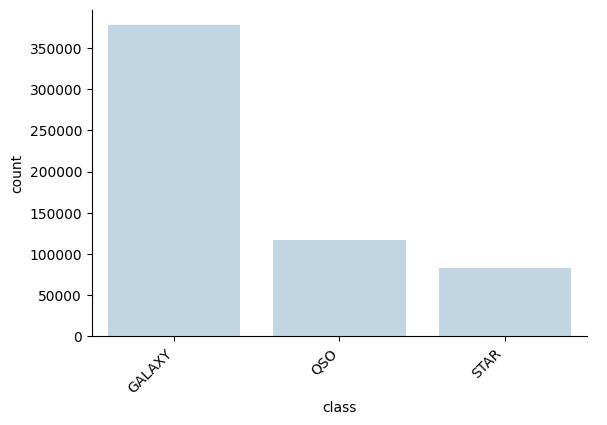

In [30]:
# the share of class
display(
    train_data['class'].value_counts(normalize=True)
    .to_frame()
    .style.background_gradient(cmap='Set3')
    .format("{:.2%}")
)

g = sns.catplot(
    data=train_data,
    x="class",
    aspect=1.5,
    height=4,
    alpha=0.3,
    kind="count",
).set_xticklabels(rotation=45, horizontalalignment="right")

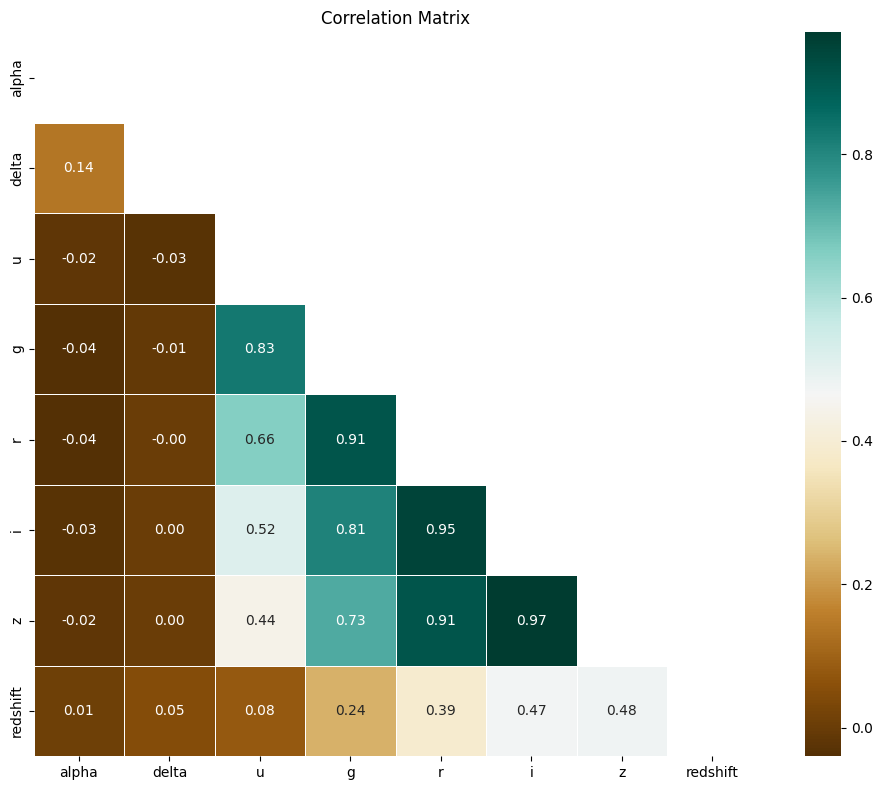

In [70]:
corr = train_data.corr(numeric_only=True).round(2)
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="BrBG", square=True, mask=mask, linewidth=0.5)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [31]:
# identifying categorial and numeric cols

train_cat_cols = list(train_data.select_dtypes(include=['object', 'str']).columns.difference(['class']))
train_num_cols = list(train_data.select_dtypes(include=np.number).columns.difference(['id']))

test_cat_cols = list(test_data.select_dtypes(include=['object', 'str']).columns.difference(['class']))
test_num_cols = list(test_data.select_dtypes(include=np.number).columns.difference(['id']))

<div style="background-color: #fffbe6; border-left: 4px solid #c8a800; padding: 10px; border-radius: 4px;"><h4>Making Pipeline</h4></div>

In [36]:
# making pipeline for LGBM model

num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])
cat_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])
preprocessor = ColumnTransformer(transformers=[
    ("num", num_transformer, train_num_cols),
    ("cat", cat_transformer, train_cat_cols)
])

lgbm = LGBMClassifier(random_state=42, verbose=-1)
pipe_lgbm = Pipeline(steps=[
    ("preproc", preprocessor),
    ("l_clf", lgbm)
])

In [37]:
# making pipeline for Catboostclassifier model

num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])
cat_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])
preprocessor = ColumnTransformer(transformers=[
    ("num", num_transformer, train_num_cols),
    ("cat", cat_transformer, train_cat_cols)
])

ctbc = CatBoostClassifier(random_state=42, verbose=0)
pipe_cat = Pipeline(steps=[
    ("preproc", preprocessor),
    ("c_clf", ctbc)
])

<div style="background-color: #fffbe6; border-left: 4px solid #c8a800; padding: 10px; border-radius: 4px;"><h4>Model Training & Hyperparameter Optimization with Optuna</h4></div>

In [38]:
y = train_data['class']
X = train_data.drop('class', axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [39]:
# silence Optuna + warnings for LGBM
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

# objective function Optuna
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1500, step=100),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 15, 50, step=5),
        "max_depth": trial.suggest_categorical("max_depth", [4, 6, 8, 10]),
        "min_child_samples": trial.suggest_int("min_child_samples", 50, 300, step=50),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0, step=0.1),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0, step=0.1),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 1.0, step=0.1),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 1.0, step=0.1),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-6, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-6, 10.0, log=True),
        "objective": "multiclass",
        "num_class": 3,
      #  "categorical_feature": train_cat_cols,
        "boosting_type": "gbdt",
        # "n_jobs": -1, # using all processors
        "verbose": -1
    }

    pipe_lgbm.set_params(**{f"l_clf__{k}": v for k, v in params.items()})

    # stratified 5-fold CV
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # compute mean Balanced Accuracy
    scores = cross_val_score(pipe_lgbm, X_train, y_train, cv=cv, scoring="balanced_accuracy", n_jobs=-1)
    mean_score = np.mean(scores)

    # controlled verbosity - print every 10th trial
    if (trial.number + 1) % 10 == 0:
        best_so_far = trial.study.best_value if trial.study.best_value is not None else mean_score
        print(f"[Trial {trial.number + 1:03}] mean balanced_accuracy: {mean_score:.5f} | best so far: {best_so_far:.5f}")

    return mean_score

In [40]:
# silence Optuna + warnings for CTBC
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

# objective function Optuna
def objective_cat(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 100, 1500, step=100),     
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "depth": trial.suggest_int("depth", 4, 10),                                
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 50, 300, step=50), 
        "bootstrap_type": "Bernoulli",
        "subsample": trial.suggest_float("subsample", 0.6, 1.0, step=0.1),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.6, 1.0, step=0.1), 
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-6, 10.0, log=True),  
        "border_count": trial.suggest_int("border_count", 32, 255),
        "loss_function": "MultiClass",                                              
        "eval_metric": "Accuracy",
      #  "cat_features": train_cat_cols,                                            
        "verbose": 0                                                                
    }

    pipe_cat.set_params(**{f"c_clf__{k}": v for k, v in params.items()})

    # stratified 5-fold CV
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # compute mean Balanced Accuracy
    scores = cross_val_score(pipe_cat, X_train, y_train, cv=cv, scoring="balanced_accuracy", n_jobs=-1)
    mean_score = np.mean(scores)

    # controlled verbosity - print every 10th trial
    if (trial.number + 1) % 10 == 0:
        best_so_far = trial.study.best_value if trial.study.best_value is not None else mean_score
        print(f"[Trial {trial.number + 1:03}] mean balanced_accuracy: {mean_score:.5f} | best so far: {best_so_far:.5f}")

    return mean_score

In [ ]:
# create or load Optuna study for LGBM
study_lgbm = optuna.create_study(
    direction="maximize",
    study_name="LGBM_balanced_accuracy",
    storage="sqlite:///lgbm_with_optuna.db",
    load_if_exists=True
)

# run optimization
study_lgbm.optimize(objective, n_trials=4, n_jobs=1, show_progress_bar=True)

# final results
print("\n===LGBM OPTIMIZATION COMPLETE ===")
print(f"best CV balanced accuracy: {study_lgbm.best_value:.5f}")
print("best params LGMC:", study_lgbm.best_params)

# visualizations
display(optuna.visualization.plot_param_importances(study_lgbm))
display(optuna.visualization.plot_optimization_history(study_lgbm))

  0%|          | 0/4 [00:00<?, ?it/s]

In [3]:
# create or load Optuna study for CTBC
study_ctbc = optuna.create_study(
    direction="maximize",
    study_name="CTBC_AUC",
    storage="sqlite:///ctbc_with_optuna.db",
    load_if_exists=True
)

# run optimization
study_ctbc.optimize(objective_cat, n_trials=10, n_jobs=1, show_progress_bar=True)

# final results
print("\n===CTBC OPTIMIZATION COMPLETE ===")
print(f"best CV balanced accuracy: {study_ctbc.best_value:.5f}")
print("best params CTBC:", study_ctbc.best_params)

# visualizations
display(optuna.visualization.plot_param_importances(study_ctbc))
display(optuna.visualization.plot_optimization_history(study_ctbc))

NameError: name 'optuna' is not defined

<div style="background-color: #fffbe6; border-left: 4px solid #c8a800; padding: 10px; border-radius: 4px;"><h4>train and saving the best models</h4></div>

In [20]:
# lgbm model
lgbm_best_params = {f"l_clf__{k}": v for k, v in study_lgbm.best_params.items()}
pipe_lgbm.set_params(**lgbm_best_params)
lgbm_best_model = pipe_lgbm.fit(X_train, y_train)

joblib.dump(lgbm_best_model, 'lgbm_best_model.joblib')

['lgbm_best_model.joblib']

In [41]:
# ctbc model 

fixed_params = {
    "bootstrap_type": "Bernoulli",
    "loss_function": "MultiClass",
    "eval_metric": "Accuracy",
    "verbose": 0,
}

ctbc_best_params = {f"c_clf__{k}": v for k, v in study_ctbc.best_params.items()}
ctbc_fixed_params = {f"c_clf__{k}": v for k, v in fixed_params.items()}
pipe_cat.set_params(**ctbc_best_params, **ctbc_fixed_params)
ctbc_best_model = pipe_cat.fit(X_train, y_train)

joblib.dump(ctbc_best_model, 'ctbc_best_model.joblib')

['ctbc_best_model.joblib']

<div style="background-color: #fffbe6; border-left: 4px solid #c8a800; padding: 10px; border-radius: 4px;"><h4>Evaluate on Validation Data</h4></div>

In [43]:
lgbm_best_model = joblib.load('lgbm_best_model.joblib')
ctbc_best_model = joblib.load('ctbc_best_model.joblib')

In [55]:
print('===' * 10, 'LGBM', '===' * 10)
y_pred_lgbm = lgbm_best_model.predict(X_test)
y_proba_lgbm = lgbm_best_model.predict_proba(X_test)
print("ROC AUC:", roc_auc_score(y_test, y_proba_lgbm, multi_class="ovr"))
print("accuracy:", accuracy_score(y_test, y_pred_lgbm))
print("\n", classification_report(y_test, y_pred_lgbm, digits=3))

print('===' * 10, 'CTBC', '===' * 10)
y_pred_ctbc = ctbc_best_model.predict(X_test)
y_proba_ctbc = ctbc_best_model.predict_proba(X_test)
print("ROC AUC:", roc_auc_score(y_test, y_proba_ctbc, multi_class="ovr"))
print("accuracy:", accuracy_score(y_test, y_pred_ctbc))
print("\n", classification_report(y_test, y_pred_ctbc, digits=3))

print('===' * 10, 'Ensemble', '===' * 10)
ensemble_proba = (lgbm_best_model.predict_proba(X_test) + ctbc_best_model.predict_proba(X_test)) / 2
ensemble_pred = lgbm_best_model.classes_[np.argmax(ensemble_proba, axis=1)]
print("ROC AUC:", roc_auc_score(y_test, ensemble_proba, multi_class="ovr"))
print("accuracy:", accuracy_score(y_test, ensemble_pred))
print("\n", classification_report(y_test, ensemble_pred, digits=3))

============================== LGBM ==============================
ROC AUC: 0.9963704051974797
accuracy: 0.9677925002165064

               precision    recall  f1-score   support

      GALAXY      0.976     0.979     0.978     75496
         QSO      0.966     0.963     0.965     23429
        STAR      0.931     0.924     0.928     16545

    accuracy                          0.968    115470
   macro avg      0.958     0.955     0.957    115470
weighted avg      0.968     0.968     0.968    115470

============================== CTBC ==============================
ROC AUC: 0.9959480729662165
accuracy: 0.9654455702779943

               precision    recall  f1-score   support

      GALAXY      0.974     0.978     0.976     75496
         QSO      0.964     0.962     0.963     23429
        STAR      0.925     0.915     0.920     16545

    accuracy                          0.965    115470
   macro avg      0.955     0.951     0.953    115470
weighted avg      0.965     0.965     0.9

<div style="background-color: #fffbe6; border-left: 4px solid #c8a800; padding: 10px; border-radius: 4px;"><h4>Visual Diagnostics</h4><p>Each section below includes a standard visualization for classification model diagnostics.</p></div>

**ROC Curve(true vs false positive rates)**

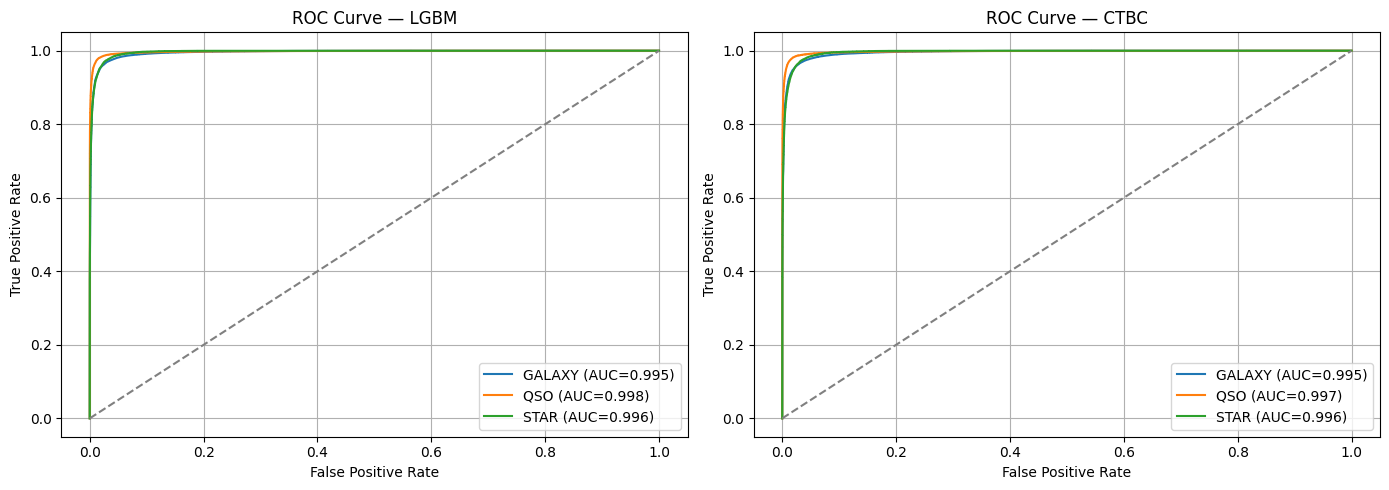

In [45]:
classes = lgbm_best_model.classes_
y_test_bin = label_binarize(y_test, classes=classes)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, name, y_proba in [
    (axes[0], "LGBM", lgbm_best_model.predict_proba(X_test)),
    (axes[1], "CTBC", ctbc_best_model.predict_proba(X_test))
]:
    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        ax.plot(fpr, tpr, label=f"{cls} (AUC={auc(fpr,tpr):.3f})")
    ax.plot([0,1], [0,1], "--", color="gray")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"ROC Curve — {name}")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

**Precision-Recall Curve**

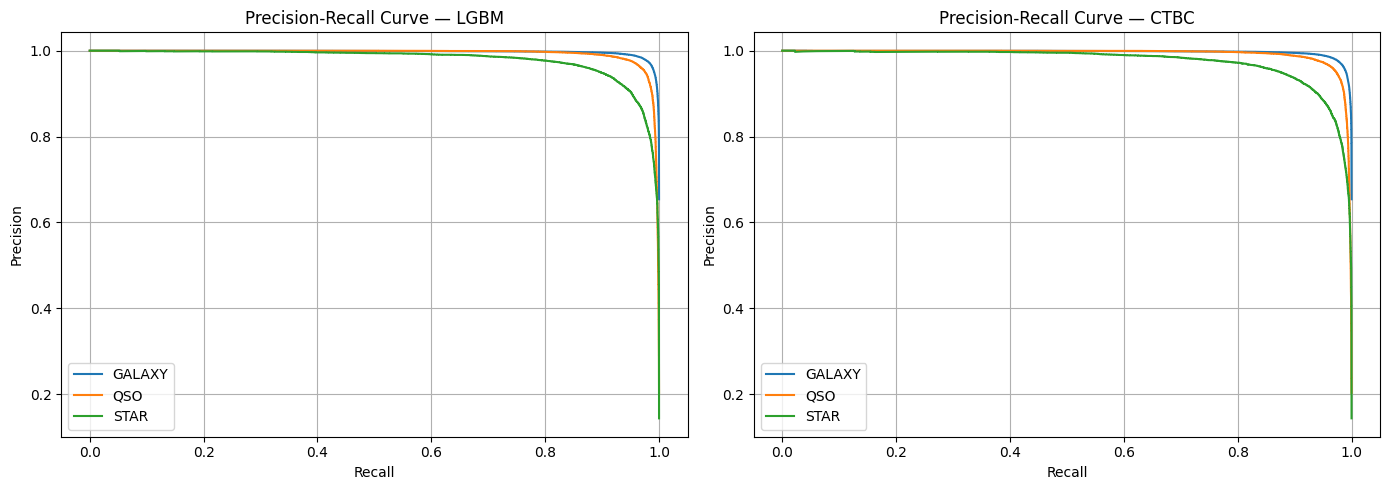

In [47]:
classes = lgbm_best_model.classes_
y_test_bin = label_binarize(y_test, classes=classes)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, name, y_proba in [
    (axes[0], "LGBM", lgbm_best_model.predict_proba(X_test)),
    (axes[1], "CTBC", ctbc_best_model.predict_proba(X_test))
]:
    for i, cls in enumerate(classes):
        prec, rec, thr = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
        ax.plot(rec, prec, label=cls)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(f"Precision-Recall Curve — {name}")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

**Feature Importances**

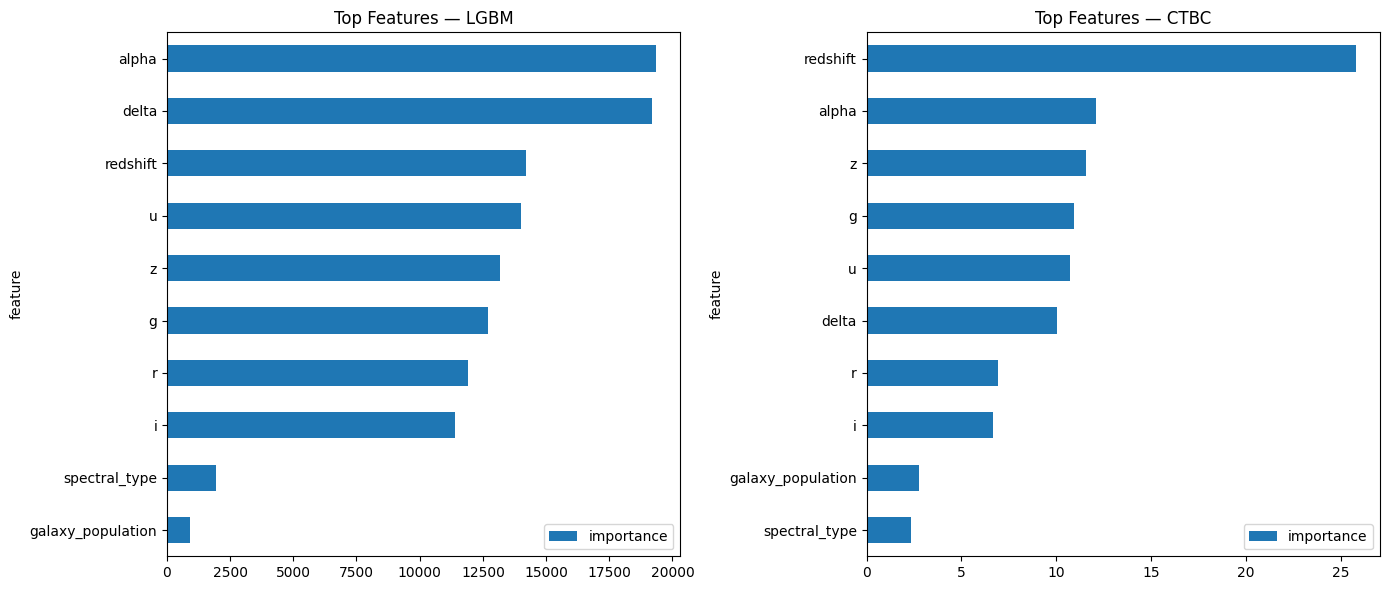

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, model, step, name in [
    (axes[0], lgbm_best_model, "l_clf", "LGBM"),
    (axes[1], ctbc_best_model, "c_clf", "CTBC")
]:
    feature_names_all = train_num_cols + train_cat_cols
    importances = model.named_steps[step].feature_importances_
    feat_imp = pd.DataFrame({"feature": feature_names_all, "importance": importances})
    feat_imp.sort_values("importance", ascending=False, inplace=True)
    feat_imp.head(15).plot.barh(x="feature", y="importance", ax=ax, title=f"Top Features — {name}")
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

**Calibration (Reliability) Plot**

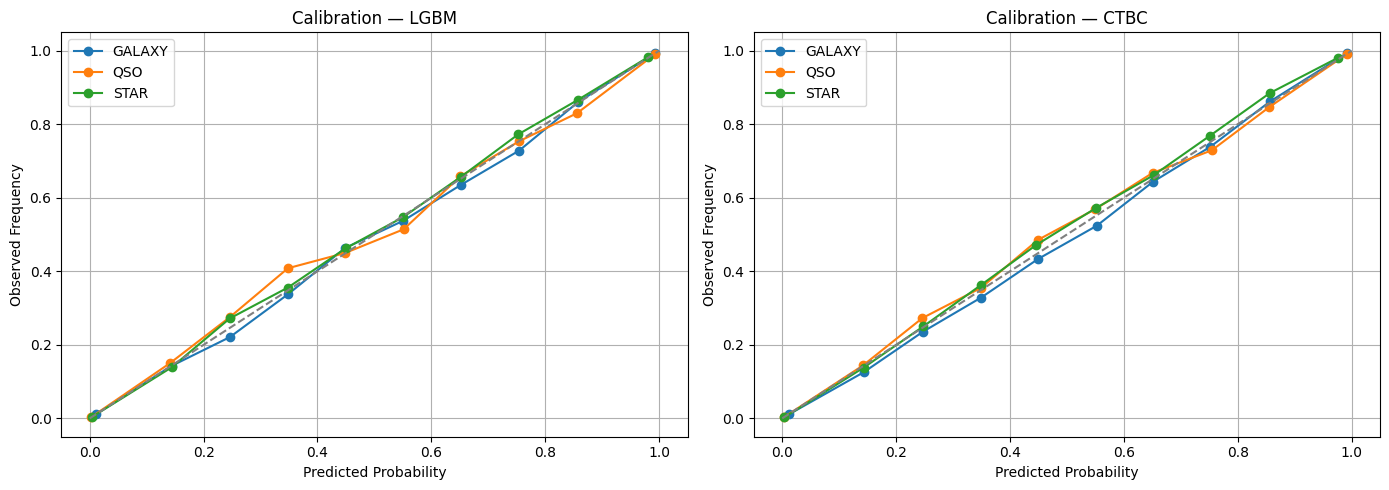

In [50]:
classes = lgbm_best_model.classes_
y_test_bin = label_binarize(y_test, classes=classes)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, name, y_proba in [
    (axes[0], "LGBM", lgbm_best_model.predict_proba(X_test)),
    (axes[1], "CTBC", ctbc_best_model.predict_proba(X_test))
]:
    for i, cls in enumerate(classes):
        prob_true, prob_pred = calibration_curve(y_test_bin[:, i], y_proba[:, i], n_bins=10)
        ax.plot(prob_pred, prob_true, "o-", label=cls)
    ax.plot([0, 1], [0, 1], "--", color="gray")
    ax.set_xlabel("Predicted Probability")
    ax.set_ylabel("Observed Frequency")
    ax.set_title(f"Calibration — {name}")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

**Confusion Matrix**

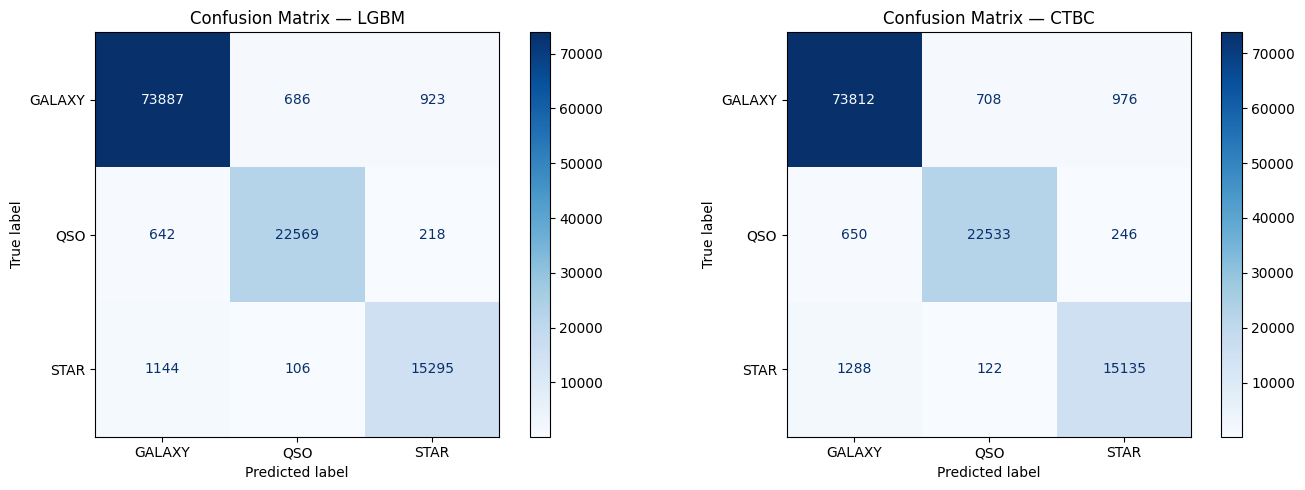

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model, name in [
    (axes[0], lgbm_best_model, "LGBM"),
    (axes[1], ctbc_best_model, "CTBC")
]:
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=model.classes_)
    disp.plot(ax=ax, cmap="Blues", values_format="d")
    ax.set_title(f"Confusion Matrix — {name}")

plt.tight_layout()
plt.show()

In [64]:
# submission

# LGBM
sub_lgbm = pd.DataFrame({"id": test_data_ids, "class": lgbm_best_model.predict(test_data)})
sub_lgbm.to_csv("submission_lgbm.csv", index=False)

# CTBC
sub_ctbc = pd.DataFrame({"id": test_data_ids, "class": ctbc_best_model.predict(test_data).flatten()})
sub_ctbc.to_csv("submission_ctbc.csv", index=False)

# Ensemble
ens_proba = (lgbm_best_model.predict_proba(test_data) + ctbc_best_model.predict_proba(test_data)) / 2
ens_pred = lgbm_best_model.classes_[np.argmax(ens_proba, axis=1)]
sub_ens = pd.DataFrame({"id": test_data_ids, "class": ens_pred})
sub_ens.to_csv("submission_ensemble.csv", index=False)

print("LGBM:", sub_lgbm["class"].value_counts().to_dict())
print("CTBC:", sub_ctbc["class"].value_counts().to_dict())
print("ensemble:", sub_ens["class"].value_counts().to_dict())

LGBM: {'GALAXY': 162132, 'QSO': 50026, 'STAR': 35277}
CTBC: {'GALAXY': 162308, 'QSO': 50058, 'STAR': 35069}
ensemble: {'GALAXY': 162258, 'QSO': 50029, 'STAR': 35148}
